# RLSSM Advanced Tutorial: Custom Models with ssms.rl

When presets are not enough, define a custom model in `ssms.rl`:

- **Task environment** — how feedback is generated
- **Learning process** — how beliefs update and map to SSM parameters
- **Decision process** — which SSM generates RT/choice

We demonstrate a **three-condition angle bandit** (AB / CD / EF blocks) with condition-specific Q-values, then infer with HSSM.

See also: [Basic](rlssm_basic.ipynb) · [Restless learner](rlssm_restless_learner.ipynb)

## Setup

In [1]:

import logging
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import hssm
import ssms.rl as rl

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

hssm.set_floatX("float32", update_jax=True)


def make_participant_theta(group_theta, sds, bounds, n, rng):
    """Sample participant-level parameters around group means."""
    theta_arrays = {}
    for name, mean in group_theta.items():
        lo, hi = bounds[name]
        theta_arrays[name] = np.clip(rng.normal(mean, sds[name], size=n), lo, hi)
    true_df = pd.DataFrame(theta_arrays)
    true_df.index.name = "participant_id"
    return theta_arrays, true_df


PARTICIPANT_EFFECT_PRIOR = {
    "name": "Normal",
    "mu": {"name": "Normal", "mu": 0, "sigma": 0.1},
    "sigma": {"name": "HalfNormal", "sigma": 0.5},
}


def hierarchical_param(name, lo, hi, mu, sigma):
    """Build a truncated-normal group mean with participant random effects."""
    return hssm.Param(
        name,
        formula=f"{name} ~ 1 + (1|participant_id)",
        prior={
            "Intercept": hssm.Prior("TruncatedNormal", lower=lo, upper=hi, mu=mu, sigma=sigma),
            "1|participant_id": PARTICIPANT_EFFECT_PRIOR,
        },
    )


def per_participant_posterior_means(idata, list_params):
  post = idata.posterior
  out = {}
  for name in list_params:
      inter = post[f"{name}_Intercept"]
      re = post[f"{name}_1|participant_id"]
      re_dim = [d for d in re.dims if d not in ("chain", "draw")][0]
      per_p = (inter + re).mean(("chain", "draw"))
      ids = [int(v) for v in re[re_dim].values]
      out[name] = pd.Series(np.asarray(per_p.values), index=ids).sort_index()
  return pd.DataFrame(out)


def plot_group_recovery(idata, list_params, group_theta, title):
    names = [f"{n}_Intercept" for n in list_params]
    summ = az.summary(idata, var_names=names, kind="stats")
    summ.index = list_params
    summ["true"] = [group_theta[n] for n in list_params]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = np.arange(len(list_params))
    ax.errorbar(
        summ["mean"],
        y,
        xerr=[summ["mean"] - summ["hdi_3%"], summ["hdi_97%"] - summ["mean"]],
        fmt="o",
        capsize=4,
        label="posterior (intercept)",
    )
    ax.scatter(summ["true"], y, color="crimson", marker="D", zorder=5, label="true group mean")
    ax.set_yticks(y)
    ax.set_yticklabels(list_params)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()
    return summ


def run_ppc(ssms_config, observed_data, ppc_theta, random_state=0):
    """Posterior predictive simulation conditioned on observed learning history."""
    return rl.Simulator(ssms_config).simulate(
        theta=ppc_theta,
        mode="ppc",
        observed_data=observed_data,
        random_state=random_state,
    )


def plot_rt_choice_ppc(observed, ppc, title="Posterior predictive check"):
    obs_rt = observed["rt"].to_numpy()
    ppc_rt = ppc["rt"].to_numpy()
    obs_rt = obs_rt[np.isfinite(obs_rt) & (obs_rt > 0)]
    ppc_rt = ppc_rt[np.isfinite(ppc_rt) & (ppc_rt > 0)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    if len(obs_rt) and len(ppc_rt):
        axes[0].hist(obs_rt, bins=25, density=True, alpha=0.5, label="observed")
        axes[0].hist(ppc_rt, bins=25, density=True, alpha=0.5, label="ppc")
    axes[0].set_title("RT distribution")
    axes[0].legend()
    obs_resp = observed["response"]
    ppc_resp = ppc["response"]
    valid = obs_resp > -900
    obs_choice = obs_resp[valid].value_counts(normalize=True).sort_index()
    valid_ppc = ppc_resp > -900
    ppc_choice = ppc_resp[valid_ppc].value_counts(normalize=True).sort_index()
    labels = sorted(set(obs_choice.index) | set(ppc_choice.index))
    x = np.arange(len(labels))
    axes[1].bar(x - 0.2, [obs_choice.get(c, 0) for c in labels], width=0.4, label="observed")
    axes[1].bar(x + 0.2, [ppc_choice.get(c, 0) for c in labels], width=0.4, label="ppc")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_title("Response proportions")
    axes[1].legend()
    fig.suptitle(title)
    plt.show()


Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


In [2]:
FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"
N_PARTICIPANTS = 12 if FULL_RUN else 4
N_TRIALS_PER_CONDITION = 60 if FULL_RUN else 20
N_CONDITIONS = 3
N_TRIALS = N_TRIALS_PER_CONDITION * N_CONDITIONS
N_CHAINS = 2
N_DRAWS = 120 if FULL_RUN else 60
N_TUNE = 120 if FULL_RUN else 60
N_PPC_DRAWS = 8 if FULL_RUN else 3
RANDOM_SEED = 20260705

CONDITIONS = [
    {"condition_id": 0, "label": "AB", "reward_probs": [0.90, 0.10]},
    {"condition_id": 1, "label": "CD", "reward_probs": [0.75, 0.25]},
    {"condition_id": 2, "label": "EF", "reward_probs": [0.60, 0.40]},
]


## Custom task environment

In [3]:
class ThreeConditionBandit:
    """Blocked three-condition Bernoulli bandit (AB, CD, EF)."""

    def __init__(self, conditions, trials_per_condition):
        self._conditions = list(conditions)
        self._trials_per = int(trials_per_condition)
        self._schedule = [
            c for c in self._conditions for _ in range(self._trials_per)
        ]
        self._rng = None

    @property
    def context_fields(self):
        return ["condition_id", "feedback"]

    @property
    def n_choices(self):
        return 2

    @property
    def response_labels(self):
        return [-1, 1]

    def reset(self, rng=None):
        self._rng = rng

    def get_trial_context(self, trial_idx):
        cond = self._schedule[trial_idx]
        return {"condition_id": float(cond["condition_id"])}

    def sample_context(self, context, trial_idx):
        cond = self._schedule[trial_idx]
        choice = int(context["choice"])
        p = cond["reward_probs"][choice]
        feedback = float(self._rng.random() < p)
        return {"feedback": feedback}


## Custom JAX learning process

In [4]:
class ConditionAwareRWLearner:
    """Rescorla–Wagner with separate Q-values per condition."""

    def __init__(self, n_conditions=3, initial_q=0.5):
        self._n_conditions = n_conditions
        self._initial_q = initial_q

    @property
    def computed_params(self):
        return ["v"]

    @property
    def free_params(self):
        return ["rl_alpha", "scaler"]

    @property
    def param_bounds(self):
        return {"rl_alpha": (0.0, 1.0), "scaler": (0.001, 10.0)}

    @property
    def default_params(self):
        return {"rl_alpha": 0.2, "scaler": 2.0}

    @property
    def available_backends(self):
        return ("python", "jax")

    @property
    def supports_gradient(self):
        return True

    @property
    def required_context_fields(self):
        return ["condition_id", "choice", "feedback"]

    def init_state(self):
        q = np.full((self._n_conditions, 2), self._initial_q, dtype=np.float64)
        return {"q_values": q}

    def init_jax_state(self):
        import jax.numpy as jnp
        return {"q_values": jnp.full((self._n_conditions, 2), self._initial_q)}

    def compute_python(self, state, params, context):
        cid = int(context["condition_id"])
        q = state["q_values"][cid]
        return {"v": float((q[1] - q[0]) * params["scaler"])}

    def compute_jax(self, state, params, context):
        import jax.numpy as jnp
        cid = jnp.int32(context["condition_id"])
        q = state["q_values"][cid]
        return {"v": (q[1] - q[0]) * params["scaler"]}

    def update_python(self, state, params, context):
        cid = int(context["condition_id"])
        choice = int(context["choice"])
        fb = float(context["feedback"])
        q = state["q_values"].copy()
        q[cid, choice] += params["rl_alpha"] * (fb - q[cid, choice])
        return {"q_values": q}

    def update_jax(self, state, params, context):
        import jax.numpy as jnp
        cid = jnp.int32(context["condition_id"])
        choice = context["choice"]
        fb = context["feedback"]
        q = state["q_values"]
        delta = params["rl_alpha"] * (fb - q[cid, choice])
        new_q = q.at[cid, choice].add(delta)
        return {"q_values": new_q}


## Assemble `ModelConfig` and simulate

In [5]:
ssms_config = rl.ModelConfig(
    model_name="3Condition_RW_Angle",
    description="Three blocked bandit conditions with condition-specific RW learning.",
    decision_process="angle",
    learning_process=ConditionAwareRWLearner(n_conditions=N_CONDITIONS),
    task_environment=ThreeConditionBandit(CONDITIONS, N_TRIALS_PER_CONDITION),
    context_fields=["condition_id", "feedback"],
)
ssms_config.validate()
assembled = ssms_config.assemble(backend="jax")
print("gradient:", assembled.gradient)
assert assembled.gradient == "available"

GROUP_THETA = {
    "rl_alpha": 0.30, "scaler": 2.0, "a": 1.2, "z": 0.5, "t": 0.25, "theta": 0.30,
}
BOUNDS = {
    "rl_alpha": (0.01, 1.0), "scaler": (0.1, 5.0), "a": (0.3, 2.5),
    "z": (0.1, 0.9), "t": (0.05, 1.0), "theta": (0.0, 1.2),
}
SDS = {k: 0.08 for k in GROUP_THETA}
LIST_PARAMS = list(GROUP_THETA)
rng = np.random.default_rng(RANDOM_SEED)
theta_arrays, true_params = make_participant_theta(
    GROUP_THETA, SDS, BOUNDS, N_PARTICIPANTS, rng
)
data = rl.Simulator(ssms_config).simulate(
    theta=theta_arrays,
    n_trials=N_TRIALS,
    n_participants=N_PARTICIPANTS,
    random_state=RANDOM_SEED,
)
ssms_config.validate_data(data).raise_for_errors()
print(data.head())

gradient: available


   participant_id  trial_id        rt  response  condition_id  feedback
0               0         0  1.629646        -1           0.0       1.0
1               0         1  0.959411         1           0.0       0.0
2               0         2  0.470750        -1           0.0       1.0
3               0         3  0.506054        -1           0.0       1.0
4               0         4  1.055932        -1           0.0       1.0


## Bridge and fit in HSSM

extra_fields: ['condition_id', 'feedback']


You supplied a model '3Condition_RW_Angle', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


User prior for '1|participant_id' on parameter 'rl_alpha' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'rl_alpha ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


User prior for '1|participant_id' on parameter 'scaler' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'scaler ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


User prior for '1|participant_id' on parameter 'a' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'a ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


...

We recommend running at least 4 chains for robust computation of convergence diagnostics


  0%|          | 0/240 [00:00<?, ?it/s]

  0%|          | 1/240 [00:00<00:25,  9.26it/s]

 59%|█████▉    | 141/240 [00:00<00:00, 800.62it/s]

100%|██████████| 240/240 [00:00<00:00, 853.27it/s]

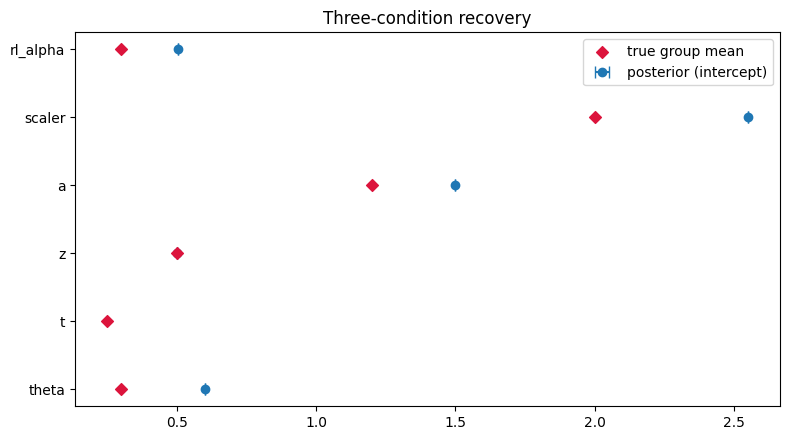

,mean,sd,hdi_3%,hdi_97%,true
rl_alpha,0.505,0.0,0.505,0.505,0.30
scaler,2.550,0.0,2.550,2.550,2.00
a,1.500,0.0,1.500,1.500,1.20
z,0.500,0.0,0.500,0.500,0.50
t,NaN,NaN,NaN,NaN,0.25
theta,0.600,0.0,0.600,0.600,0.30


In [6]:
model_config = hssm.rl.RLSSMConfig.from_ssms_model(ssms_config)
print("extra_fields:", model_config.extra_fields)
assert "condition_id" in model_config.extra_fields
model = hssm.RLSSM(
    data=data,
    model_config=model_config,
    p_outlier=0,
    lapse=None,
    include=[
        hierarchical_param("rl_alpha", 0.01, 1.0, 0.30, 0.15),
        hierarchical_param("scaler", 0.1, 5.0, 2.0, 0.8),
        hierarchical_param("a", 0.3, 2.5, 1.1, 0.3),
        hierarchical_param("z", 0.1, 0.9, 0.5, 0.15),
        hierarchical_param("t", 0.05, 1.0, 0.25, 0.1),
        hierarchical_param("theta", 0.0, 1.2, 0.30, 0.15),
    ],
)
idata = model.sample(
    draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS, cores=N_CHAINS,
    sampler="numpyro", target_accept=0.9, random_seed=RANDOM_SEED,
)
summ = plot_group_recovery(idata, LIST_PARAMS, GROUP_THETA, "Three-condition recovery")
summ

## Multi-draw PPC

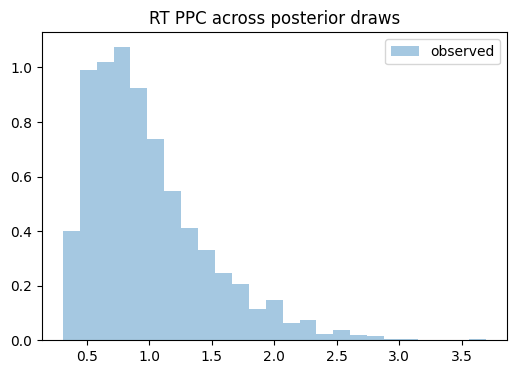

In [7]:
post = idata.posterior
ppc_rts = []
draw_idx = np.linspace(0, post.sizes['draw'] - 1, N_PPC_DRAWS, dtype=int)
for d in draw_idx:
    ppc_theta = {}
    for name in LIST_PARAMS:
        inter = float(post[f'{name}_Intercept'].isel(chain=0, draw=d).values)
        re = post[f'{name}_1|participant_id'].isel(chain=0, draw=d)
        re_dim = [x for x in re.dims if x not in ('chain', 'draw')][0]
        ppc_theta[name] = inter + re.values
    sim = run_ppc(ssms_config, data, ppc_theta, random_state=RANDOM_SEED + int(d))
    ppc_rts.append(sim['rt'].to_numpy())
ppc_rt_pool = np.concatenate(ppc_rts)
ppc_rt_pool = ppc_rt_pool[np.isfinite(ppc_rt_pool) & (ppc_rt_pool > 0)]
obs_rt = data['rt'].to_numpy()
obs_rt = obs_rt[np.isfinite(obs_rt) & (obs_rt > 0)]
fig, ax = plt.subplots(figsize=(6, 4))
if len(obs_rt):
    ax.hist(obs_rt, bins=25, density=True, alpha=0.4, label='observed')
if len(ppc_rt_pool):
    ax.hist(ppc_rt_pool, bins=25, density=True, alpha=0.4, label=f'ppc ({N_PPC_DRAWS} draws)')
ax.legend()
ax.set_title('RT PPC across posterior draws')
plt.show()